**Búsquedas No informadas** <br>




**Pathfinding.js (Simulación Web) 🌐**<br>
💡 **Descripción:**<br>
Una biblioteca en JavaScript que permite visualizar BFS, DFS, A, Dijkstra, etc.* en una cuadrícula interactiva.

💻 Dónde probar:
🔗 https://qiao.github.io/PathFinding.js/visual/

📌 Ejemplo de práctica:

Los estudiantes pueden dibujar un laberinto personalizado y probar diferentes algoritmos de búsqueda.
Comparar BFS vs. DFS y ver cuál es más eficiente en distintos escenarios
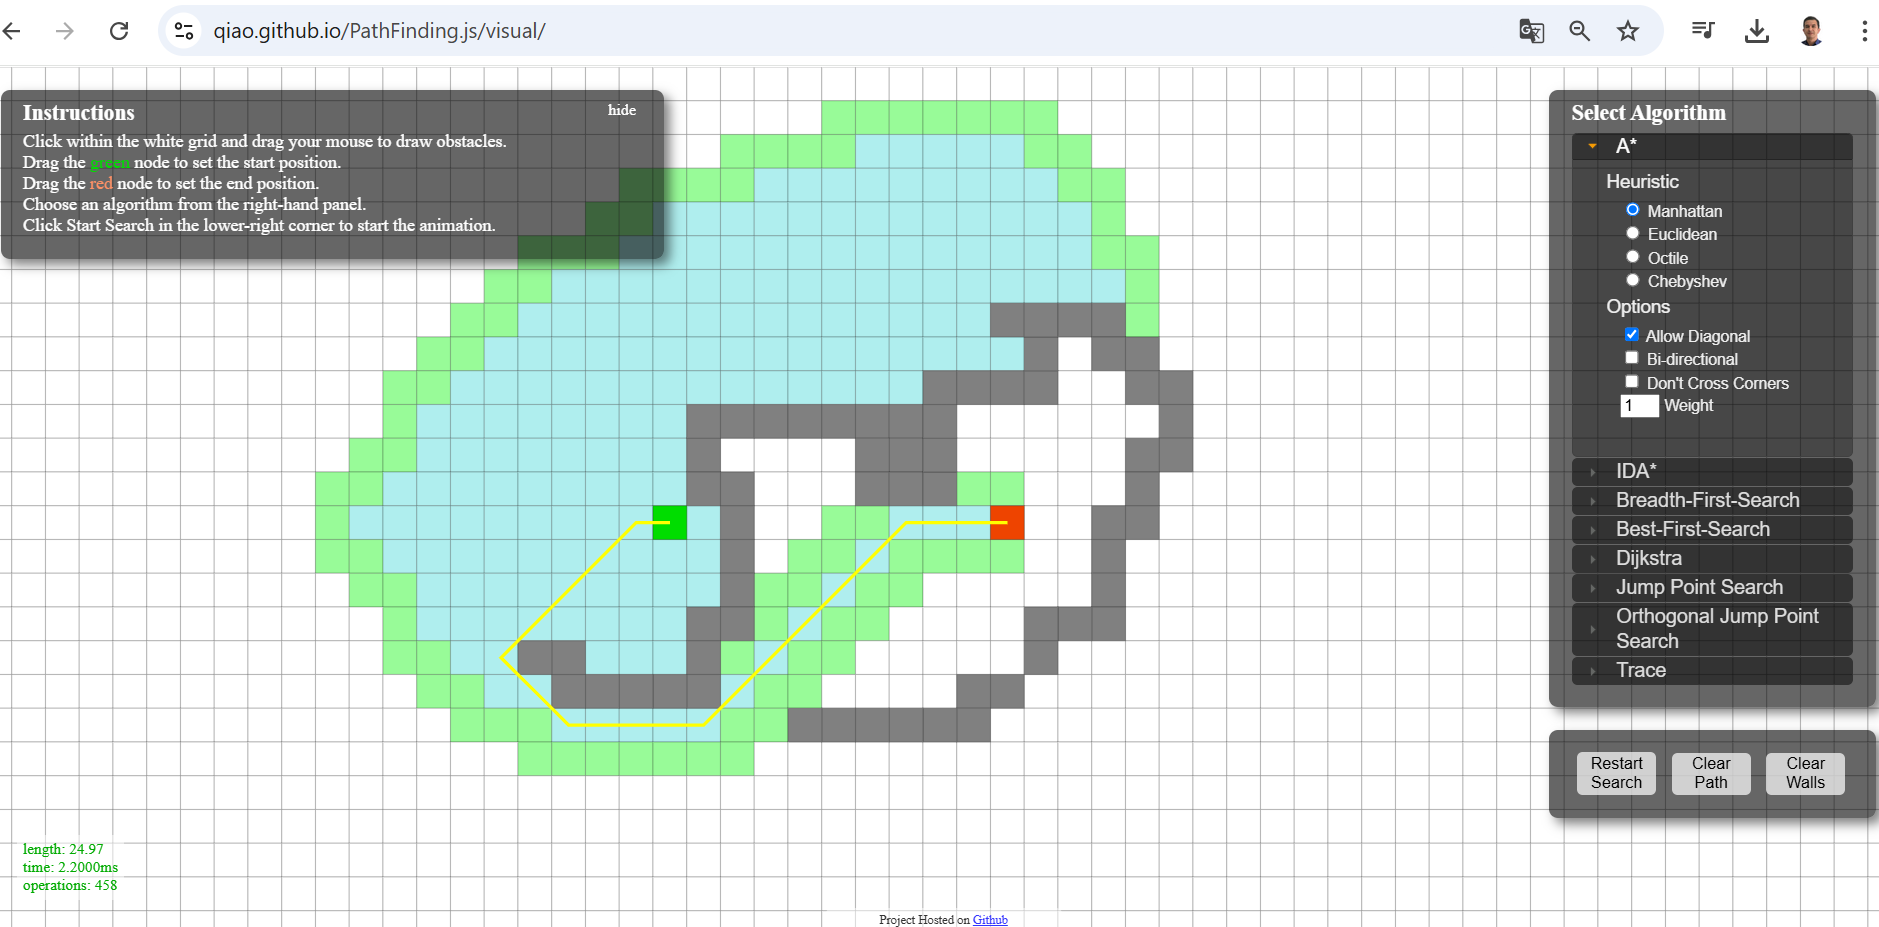

**Ejercicio 1**<br>
**Ejercicio 1: Laberinto (Búsqueda en Anchura - BFS)**<br>
**Descripción:**
Dado un laberinto representado por una matriz
𝑁
×
𝑀 ..
con celdas libres (0) y muros (1), encuentra el camino más corto desde la entrada hasta la salida. <br>

**Razón de usar BFS:** <br>
La búsqueda en anchura (BFS) es ideal porque explora los caminos en orden de menor profundidad primero, garantizando que la primera solución encontrada sea la más corta.

**Sugerencias  Solución:**
Representamos el laberinto como un grafo o matriz , donde cada celda es un nodo y las celdas adyacentes conectadas son aristas.<br>
Aplicamos BFS desde la celda de inicio, explorando en orden las celdas vecinas (arriba, abajo, izquierda, derecha).
Mantenemos un registro de las celdas visitadas para evitar ciclos.
Cuando alcanzamos la celda de salida, reconstruimos el camino óptimo.
Ejemplo:

In [70]:
from collections import deque

def bfs_laberinto(laberinto, inicio, fin):
    filas, cols = len(laberinto), len(laberinto[0])
    movimientos = [(0,1), (0,-1), (1,0), (-1,0)]
    cola = deque([(inicio, [inicio])])

    while cola:
        (x, y), path = cola.popleft()

        if (x, y) == fin:
            return path  # Camino más corto encontrado #

        for dx, dy in movimientos:
            nx, ny = x + dx, y + dy
            if 0 <= nx < filas and 0 <= ny < cols and laberinto[nx][ny] == 0:
                laberinto[nx][ny] = 2  # Marcar como visitado
                cola.append(((nx, ny), path + [(nx, ny)]))

    return None  # No hay solución


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

class GeneradorLaberinto:
    """Clase para generar y manipular laberintos con líneas horizontales y verticales."""

    def __init__(self, ancho=21, alto=21):
        """Inicializa un generador de laberintos."""
        self.ancho = ancho
        self.alto = alto
        self.laberinto = np.zeros((alto, ancho), dtype=int)

    def crear_lineas_horizontales(self, num_lineas=5):
        """Agrega líneas horizontales al laberinto."""
        for _ in range(num_lineas):
            # Seleccionar una fila aleatoria
            fila = random.randint(1, self.alto-2)
            # Seleccionar inicio y fin para esta línea horizontal
            inicio = random.randint(0, self.ancho-5)
            longitud = random.randint(5, self.ancho-inicio)
            # Crear la línea horizontal
            self.laberinto[fila, inicio:inicio+longitud] = 1

            # Añadir un hueco aleatorio en la línea para que sea atravesable
            if longitud > 3:
                hueco = random.randint(inicio+1, inicio+longitud-2)
                self.laberinto[fila, hueco] = 0

        return self.laberinto

    def crear_lineas_verticales(self, num_lineas=5):
        """Agrega líneas verticales al laberinto."""
        for _ in range(num_lineas):
            # Seleccionar una columna aleatoria
            columna = random.randint(1, self.ancho-2)
            # Seleccionar inicio y fin para esta línea vertical
            inicio = random.randint(0, self.alto-5)
            longitud = random.randint(5, self.alto-inicio)
            # Crear la línea vertical
            self.laberinto[inicio:inicio+longitud, columna] = 1

            # Añadir un hueco aleatorio en la línea para que sea atravesable
            if longitud > 3:
                hueco = random.randint(inicio+1, inicio+longitud-2)
                self.laberinto[hueco, columna] = 0

        return self.laberinto

    def obtener_laberinto(self):
        """Retorna la matriz del laberinto."""
        return self.laberinto


def bfs_laberinto_con_estados(laberinto, inicio, final):
    """
    Busca un camino en el laberinto usando BFS y registra los estados para animación.

    Args:
        laberinto: Matriz numpy que representa el laberinto (0=camino, 1=muro)
        inicio: Tupla (fila, columna) con la posición inicial
        final: Tupla (fila, columna) con la posición final

    Returns:
        Tupla con: (camino encontrado o None, lista de estados para animación)
    """
    # Obtener dimensiones
    alto, ancho = laberinto.shape

    # Asegurar que los puntos de inicio y fin están libres
    laberinto[inicio] = 0
    laberinto[final] = 0

    # Lista para almacenar estados
    estados = []

    # Conjunto para almacenar nodos visitados
    visitados = set()

    # Cola para BFS y registro de nodos ya procesados
    cola = deque([(inicio, [])])
    nodos_en_cola = {inicio}  # Conjunto para rastrear nodos actualmente en la cola

    # Añadir estado inicial
    estados.append({
        'matriz': laberinto.copy(),
        'visitados': set(),
        'frontera': set(nodos_en_cola),
        'camino_actual': [],
        'camino_final': None
    })

    # Movimientos posibles: arriba, abajo, izquierda, derecha
    movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while cola:
        (x, y), camino = cola.popleft()
        pos_actual = (x, y)

        # Quitar de la frontera (con verificación segura)
        nodos_en_cola.discard(pos_actual)

        # Si ya visitamos esta posición, continuar
        if pos_actual in visitados:
            continue

        # Marcar como visitado
        visitados.add(pos_actual)

        # Nuevo camino hasta este punto
        camino_actual = camino + [pos_actual]

        # Si llegamos al punto final
        if pos_actual == final:
            # Registrar estado final
            estados.append({
                'matriz': laberinto.copy(),
                'visitados': set(visitados),
                'frontera': set(nodos_en_cola),
                'camino_actual': camino_actual,
                'camino_final': camino_actual
            })
            return camino_actual, estados

        # Explorar vecinos
        for dx, dy in movimientos:
            nx, ny = x + dx, y + dy
            nueva_pos = (nx, ny)

            # Verificar límites y que sea camino (no muro)
            if (0 <= nx < alto and 0 <= ny < ancho and
                laberinto[nx, ny] == 0 and
                nueva_pos not in visitados and
                nueva_pos not in nodos_en_cola):

                cola.append((nueva_pos, camino_actual))
                nodos_en_cola.add(nueva_pos)

        # Registrar estado después de procesar este nodo
        estados.append({
            'matriz': laberinto.copy(),
            'visitados': set(visitados),
            'frontera': set(nodos_en_cola),
            'camino_actual': camino_actual,
            'camino_final': None
        })

    # No se encontró camino
    return None, estados


def crear_animacion_laberinto(laberinto, inicio, final, estados):
    """
    Crea una animación interactiva del recorrido BFS en el laberinto.

    Args:
        laberinto: Matriz numpy que representa el laberinto
        inicio: Tupla (fila, columna) con la posición inicial
        final: Tupla (fila, columna) con la posición final
        estados: Lista de diccionarios con los estados del algoritmo

    Returns:
        Animación HTML para mostrar en Jupyter
    """
    # Crear figura y ejes
    fig, ax = plt.subplots(figsize=(10, 10))

    # Definir colores para la visualización
    cmap = mcolors.ListedColormap(['white', 'black', 'lightgreen', 'yellow', 'blue', 'red', 'green'])
    bounds = [0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Crear una matriz para colorear
    def actualizar_matriz_colores(estado, matriz_base):
        # Copiar la matriz base (0=camino, 1=muro)
        matriz_color = matriz_base.copy()

        # Marcar celdas visitadas (valor 2)
        for x, y in estado['visitados']:
            if (x, y) != inicio and (x, y) != final:
                matriz_color[x, y] = 2

        # Marcar celdas en frontera (valor 3)
        for x, y in estado['frontera']:
            if (x, y) != inicio and (x, y) != final:
                matriz_color[x, y] = 3

        # Marcar camino actual (valor 4)
        for x, y in estado['camino_actual']:
            if (x, y) != inicio and (x, y) != final:
                matriz_color[x, y] = 4

        # Marcar inicio y final
        matriz_color[inicio] = 5  # Inicio (verde)
        matriz_color[final] = 6   # Final (rojo)

        return matriz_color

    # Matriz inicial de colores
    matriz_colores = actualizar_matriz_colores(estados[0], laberinto)

    # Crear la visualización inicial
    im = ax.imshow(matriz_colores, cmap=cmap, norm=norm)

    # Añadir leyenda
    legend_elements = [
        mpatches.Patch(color='white', label='Camino'),
        mpatches.Patch(color='black', label='Muro'),
        mpatches.Patch(color='lightgreen', label='Visitado'),
        mpatches.Patch(color='yellow', label='Frontera'),
        mpatches.Patch(color='blue', label='Camino actual'),
        mpatches.Patch(color='green', label='Inicio'),
        mpatches.Patch(color='red', label='Fin')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

    texto_estado = ax.text(0.5, -0.05, "", size=12, ha="center", transform=ax.transAxes)

    def actualizar(frame):
        # Actualizar la matriz de colores según el estado actual
        matriz_colores = actualizar_matriz_colores(estados[frame], laberinto)
        im.set_array(matriz_colores)

        # Actualizar texto de información
        texto = f"Paso {frame+1}/{len(estados)}"
        texto += f"\nNodos visitados: {len(estados[frame]['visitados'])}"
        texto += f"\nNodos en frontera: {len(estados[frame]['frontera'])}"

        if estados[frame]['camino_final'] is not None:
            texto += f"\n¡Camino encontrado! Longitud: {len(estados[frame]['camino_final'])}"

        texto_estado.set_text(texto)

        return [im, texto_estado]

    # Crear la animación
    ani = FuncAnimation(fig, actualizar, frames=len(estados),
                        interval=500, blit=True)

    plt.close()  # Para evitar que se muestre la figura estática

    return HTML(ani.to_jshtml())


def main():
    # Configurar semilla aleatoria para reproducibilidad
    random.seed(42)
    np.random.seed(42)

    # Crear el generador de laberintos
    generador = GeneradorLaberinto(ancho=21, alto=21)

    # Crear líneas horizontales y verticales
    generador.crear_lineas_horizontales(num_lineas=5)
    laberinto = generador.crear_lineas_verticales(num_lineas=5)

    # Definir puntos de inicio y fin
    inicio = (0, 0)
    final = (20, 20)

    # Asegurar que los puntos de inicio y fin están libres
    laberinto[inicio] = 0
    laberinto[final] = 0

    # Buscar un camino y registrar estados para animación
    camino, estados = bfs_laberinto_con_estados(laberinto, inicio, final)

    # Mostrar información sobre el camino
    if camino:
        print(f"¡Encontrado camino de longitud {len(camino)}!")
    else:
        print("No se encontró un camino.")

    # Crear animación
    animacion = crear_animacion_laberinto(laberinto, inicio, final, estados)

    return animacion


# Para ejecutar en Jupyter Notebook
if __name__ == "__main__":
    animacion = main()
    display(animacion)  # Muestra la animación en el notebook

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
bfs_laberinto()

**Ejercicio 2** <br>
 **Generación de Sudoku (Búsqueda en Profundidad - DFS)** <br>
Descripción:
Generar un tablero de Sudoku válido siguiendo las reglas del juego: cada fila, columna y región de
3
×
3
 <br> contiene los números del 1 al 9 sin repetir.

**Razón de usar DFS:** <br>
DFS con backtracking permite probar diferentes configuraciones hasta encontrar una válida, explorando soluciones en profundidad antes de retroceder.  <br>

**Sugerenacias para la solución:**  <br>
Se crea una cuadrícula de 9x9 con algunas celdas predefinidas.
DFS intenta llenar cada celda vacía con un número del 1 al 9.
Si un número no cumple las reglas del Sudoku, se retrocede y prueba otro.
Si el Sudoku se llena completamente, se retorna la solución.



In [ ]:
def es_valido(sudoku, fila, col, num):
    for i in range(9):
        if sudoku[fila][i] == num or sudoku[i][col] == num:
            return False
    box_x, box_y = (fila // 3) * 3, (col // 3) * 3
    for i in range(3):
        for j in range(3):
            if sudoku[box_x + i][box_y + j] == num:
                return False
    return True

def resolver_sudoku(sudoku):
    for fila in range(9):
        for col in range(9):
            if sudoku[fila][col] == 0:
                for num in range(1, 10):
                    if es_valido(sudoku, fila, col, num):
                        sudoku[fila][col] = num
                        if resolver_sudoku(sudoku):
                            return True
                        sudoku[fila][col] = 0
                return False
    return True


**Ejercicio 3** <br>
**Ruta Más Barata en un Mapa (Búsqueda de Coste Uniforme - UCS)** <BR>
**Descripción:** <BR>
Dado un conjunto de ciudades conectadas por carreteras con costos distintos, encontrar la ruta más barata entre dos ciudades.

**Razón de usar UCS:**
UCS siempre expande el nodo con menor costo acumulado primero, garantizando la solución óptima en términos de costo.

**Sugerencias para la solución:** <br>
Representamos el problema como un grafo ponderado.
Utilizamos una cola de prioridad para explorar primero las rutas más baratas.  <br>
Cuando llegamos al destino, tenemos el camino de menor costo

In [ ]:
### plantilla preliminar
import heapq

def ucs(grafo, inicio, destino):
    pq = [(0, inicio, [])]  # (coste acumulado, nodo actual, camino)
    visitados = set()

    while pq:
        costo, nodo, camino = heapq.heappop(pq)
        if nodo in visitados:
            continue
        camino = camino + [nodo]
        visitados.add(nodo)

        if nodo == destino:
            return camino, costo  # Devolvemos la ruta y su costo

        for vecino, peso in grafo.get(nodo, []):
            if vecino not in visitados:
                heapq.heappush(pq, (costo + peso, vecino, camino))

    return None  # No hay camino
